# Functions


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from pytz import timezone
from dash import Dash, html, dcc
import plotly.express as px
import plotly.subplots as sp
import plotly.figure_factory as ff
import plotly.graph_objects as go

In [9]:
eg_holidays = holidays.EG(language='en_US')

def count_items_in_order(lineitem_Qty):
    return sum([int(x) for x in lineitem_Qty])

def get_holiday_name(date):
    return eg_holidays.get(date)


In [10]:
df = pd.read_csv('depi_grouped.csv')

# UNDERSTANDING THE DATA

In [11]:
df.head()

,Name,Created at,Subtotal,Shipping,Total,Discount Amount,Shipping Method,Shipping Province,Shipping Province Name,Payment Method,Lineitem name,Lineitem price,Lineitem compare at price,Lineitem sku,Lineitem quantity,Lineitem discount,Cancelled at,Refunded Amount
0,#MC14035,2022-11-01 00:32:29 +0200,1150.0,0.0,1150.0,95.0,Free Shipping,C,Cairo,Cash on Delivery (COD),Hand Towels ( 30cm x 30 cm ) - 30x30 / Off Whi...,"35.0, 115.0, 115.0, 120.0, 95.0, 95.0","nan, nan, nan, nan, nan, nan","2017982, 2017976, 2017976, 2020742, 2020741, 2...","10, 2, 1, 3, 1, 1","0.0, 0.0, 0.0, 0.0, 0.0, 95.0",NaN,0.0
1,#MC14036,2022-11-01 04:58:48 +0200,620.0,50.0,670.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),Bath mat towel ( foot pattern ) size 50x70 - 5...,"130.0, 360.0","nan, 0.0","2018550, 2013627-white","2, 1","0.0, 0.0",NaN,0.0
2,#MC14037,2022-11-01 07:49:44 +0200,440.0,50.0,490.0,0.0,Shipping Rate,GZ,Giza,Cash on Delivery (COD),MATTRESS TOPPER - 160x200 / White / 5 cm,440.0,0.0,2021306-white,1,0.0,NaN,0.0
3,#MC14038,2022-11-01 08:08:38 +0200,600.0,50.0,650.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),Plain Bathrobe - M / Navy,600.0,0.0,2016626-Navy,1,0.0,NaN,0.0
4,#MC14039,2022-11-01 08:21:14 +0200,408.0,50.0,458.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),Face Towel 60x120 - 60x120 / off white,68.0,135.0,2013822-off white,6,0.0,NaN,0.0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24894 entries, 0 to 24893
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Name                       24894 non-null  object 
 1   Created at                 24894 non-null  object 
 2   Subtotal                   24894 non-null  float64
 3   Shipping                   24894 non-null  float64
 4   Total                      24894 non-null  float64
 5   Discount Amount            24894 non-null  float64
 6   Shipping Method            24894 non-null  object 
 7   Shipping Province          24894 non-null  object 
 8   Shipping Province Name     24894 non-null  object 
 9   Payment Method             24894 non-null  object 
 10  Lineitem name              24894 non-null  object 
 11  Lineitem price             24894 non-null  object 
 12  Lineitem compare at price  22657 non-null  object 
 13  Lineitem sku               24856 non-null  obj

In [13]:
df.isnull().sum()

Name                             0
Created at                       0
Subtotal                         0
Shipping                         0
Total                            0
Discount Amount                  0
Shipping Method                  0
Shipping Province                0
Shipping Province Name           0
Payment Method                   0
Lineitem name                    0
Lineitem price                   0
Lineitem compare at price     2237
Lineitem sku                    38
Lineitem quantity                0
Lineitem discount                0
Cancelled at                 21533
Refunded Amount                  0
dtype: int64

In [14]:
df[df['Lineitem sku'].isnull()]

,Name,Created at,Subtotal,Shipping,Total,Discount Amount,Shipping Method,Shipping Province,Shipping Province Name,Payment Method,Lineitem name,Lineitem price,Lineitem compare at price,Lineitem sku,Lineitem quantity,Lineitem discount,Cancelled at,Refunded Amount
3507,#MC17545,2023-03-25 11:33:55 +0200,1022.0,0.0,1022.0,0.0,Free Shipping,SU,6th of October,Cash on Delivery (COD),Chess Coverlet - Off White / 225 X 255,1022.0,1550.0,NaN,1,0.0,NaN,0.00
4006,#MC18044,2023-04-24 04:23:13 +0200,399.0,50.0,449.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),Mix & Match Towel Set,399.0,588.0,NaN,1,0.0,2023-04-24 05:21:55 +0200,0.00
4014,#MC18052,2023-04-24 14:57:00 +0200,239.0,50.0,289.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),Versace Bathmat,239.0,478.0,NaN,1,0.0,2023-04-24 15:29:44 +0200,0.00
4015,#MC18053,2023-04-24 15:07:21 +0200,285.0,50.0,335.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),The Cool Chef Set,285.0,410.0,NaN,1,0.0,2023-04-24 15:29:17 +0200,0.00
4132,#MC18170,2023-05-03 19:05:50 +0300,399.0,50.0,449.0,0.0,Shipping Rate,SU,6th of October,Cash on Delivery (COD),Mix & Match Towel Set,399.0,588.0,NaN,1,0.0,2023-05-03 19:44:02 +0300,0.00
4235,#MC18273,2023-05-11 10:49:48 +0300,1368.0,50.0,1418.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),Royal Tender Jacquard Set,684.0,992.0,NaN,2,0.0,2023-05-11 12:24:23 +0300,0.00
4263,#MC18301,2023-05-14 11:40:21 +0300,1150.0,50.0,1200.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),Mattress Care Set - 160x200 - Grey,1150.0,1565.0,NaN,1,0.0,2023-05-14 12:30:16 +0300,0.00
4271,#MC18309,2023-05-15 12:22:58 +0300,1400.0,50.0,1450.0,0.0,Shipping Rate,HU,Helwan,Cash on Delivery (COD),Mattress Care Set - 100x200 - Grey,700.0,968.0,NaN,2,0.0,2023-05-15 12:35:10 +0300,1450.00
4361,#MC18399,2023-05-25 19:55:03 +0300,930.0,50.0,980.0,0.0,Shipping Rate,SU,6th of October,Cash on Delivery (COD),Basic Mix Set - Beige Bathmat / Olive Bath Towel,930.0,1270.0,NaN,1,0.0,2023-05-25 21:06:20 +0300,0.00
4514,#MC18552,2023-06-04 03:04:41 +0300,945.0,50.0,995.0,0.0,Shipping Rate,C,Cairo,Cash on Delivery (COD),Honeymoon Set - XXL / Coffee,945.0,NaN,NaN,1,0.0,2023-06-04 15:59:36 +0300,0.00


In [15]:
# Drop remaining rows with null SKUs
null_count_before = df['Lineitem sku'].isnull().sum()
df = df.dropna(subset=['Lineitem sku'])
null_count_after = df['Lineitem sku'].isnull().sum()

print(f"Null SKUs before: {null_count_before}")
print(f"Null SKUs after: {null_count_after}")
print(f"Rows dropped: {null_count_before - null_count_after}")



Null SKUs before: 38
Null SKUs after: 0
Rows dropped: 38


In [16]:
df.describe()

,Subtotal,Shipping,Total,Discount Amount,Refunded Amount
count,24856.000000,24856.000000,24856.000000,24856.000000,24856.000000
mean,1799.557938,44.270985,1843.857085,427.393510,18.362152
std,2137.330703,45.778163,2130.678760,1065.425613,215.983489
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,615.000000,0.000000,660.000000,0.000000,0.000000
50%,1190.000000,50.000000,1210.000000,0.000000,0.000000
75%,2200.000000,60.000000,2230.000000,400.000000,0.000000
max,54091.000000,703.000000,54091.000000,55837.340000,10150.000000


In [17]:
# df2 = pd.read
df['Created at'] = pd.to_datetime(df['Created at'],format='%Y-%m-%d %H:%M:%S %z',utc=True)
df['Created at'] = df['Created at'].dt.tz_convert(timezone('Etc/GMT-2'))

df['hour'] = df['Created at'].dt.hour
df['month'] = df['Created at'].dt.month

df['day_of_week'] = df['Created at'].dt.day_name()

df['year'] = df['Created at'].dt.year
df['year_month'] = df['Created at'].dt.to_period('M')


df['season'] = pd.cut(df['Created at'].dt.month, 
                     bins=[0,3,6,9,12], 
                     labels=['Winter', 'Spring', 'Summer', 'Fall'])


df['holiday_name'] = df['Created at'].apply(get_holiday_name)
df['is_holiday'] = df['holiday_name'].notna()
df['is_weekend'] = df['Created at'].dt.dayofweek.isin([4, 5])
df['day_type'] = 'Weekday'
df.loc[df['is_weekend'], 'day_type'] = 'Weekend'
df.loc[df['is_holiday'], 'day_type'] = 'Holiday'


df['Lineitem price'] = df['Lineitem price'].str.split(',').apply(lambda x: [float(p) for p in x])
df['Lineitem name'] = df['Lineitem name'].str.split(',').apply(lambda x: [item.strip() for item in x])
df['Lineitem quantity'] = df['Lineitem quantity'].str.split(',').apply(lambda x: [int(q) for q in x])
df['Lineitem sku'] = df['Lineitem sku'].str.split(',').apply(lambda x: [sku.strip() for sku in x])
df['Lineitem discount'] = df['Lineitem discount'].str.split(',').apply(lambda x: [float(d) for d in x])

df['item_count']= df['Lineitem quantity'].apply(count_items_in_order)



C:\Users\MH\AppData\Local\Temp\ipykernel_11348\3528190339.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['Created at'].dt.to_period('M')


# GRAPHS FOR THE DATA BEFORE PROCESSING IT

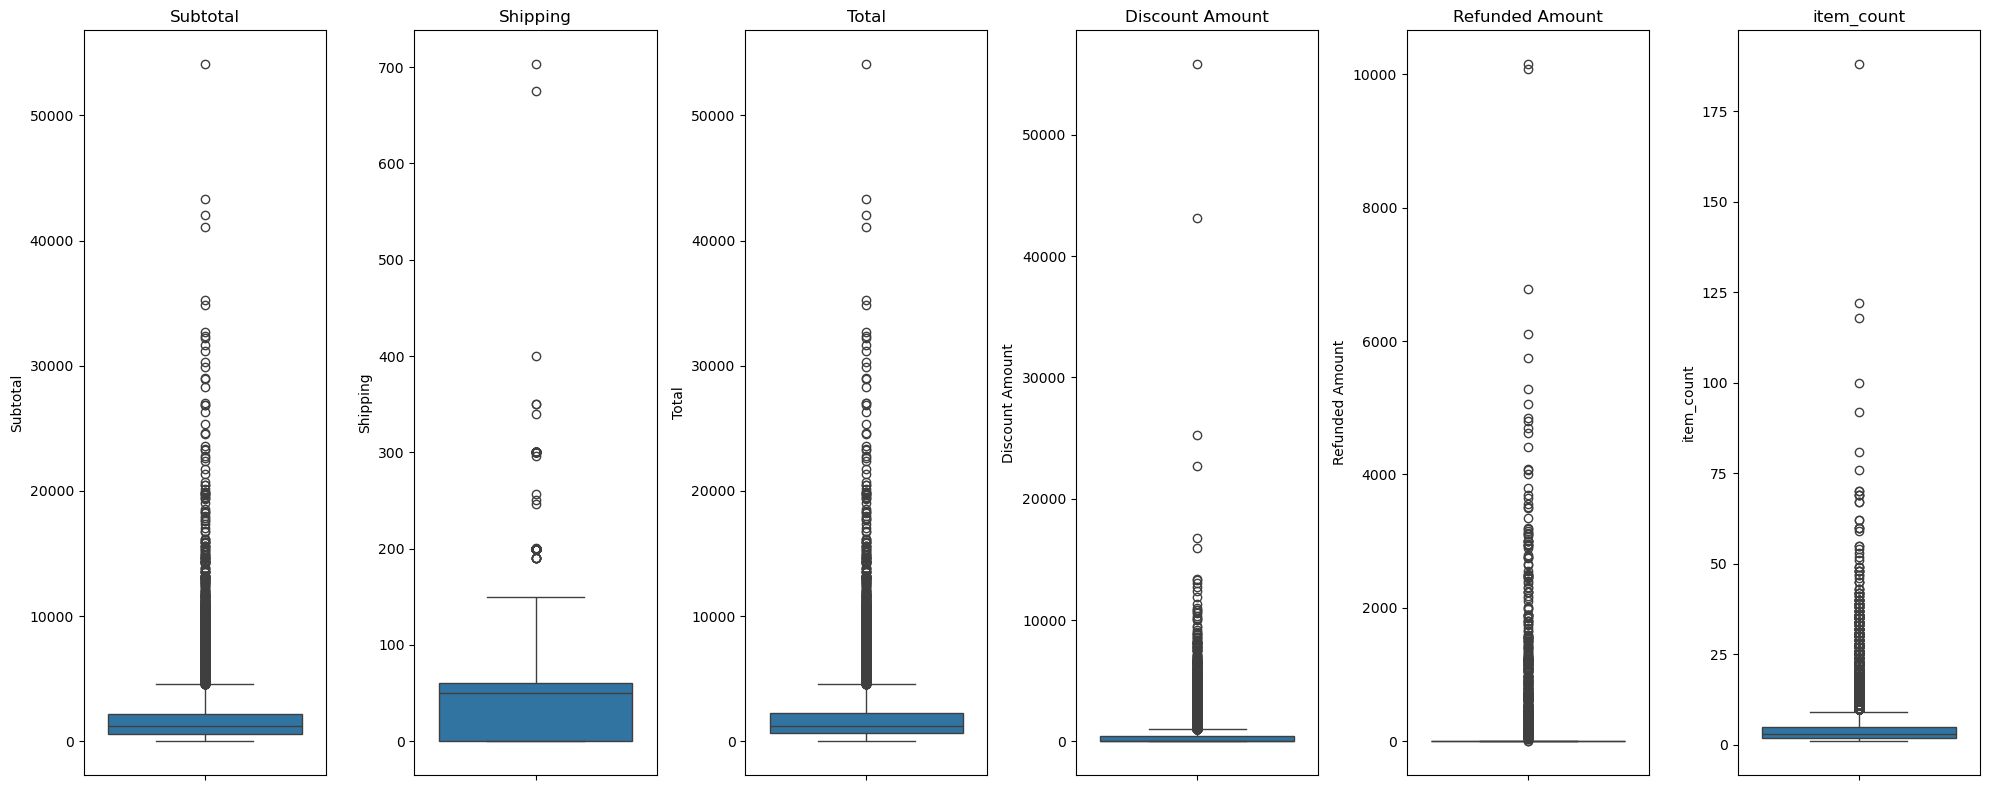

In [18]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(20, 8))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(1, len(numerical_columns), i) 
    sns.boxplot(y=df[column])
    plt.title(column)
    
plt.tight_layout()
plt.show()

In [72]:
fig = sp.make_subplots(rows=1, cols=len(numerical_columns))

for i, column in enumerate(numerical_columns, 1):
    fig.add_trace(go.Box(y=df[column], name=column), row=1, col=i)

fig.update_layout(
    title_text="Boxplots of Numerical Columns",
    showlegend=False,
    height=500,
    width=2000
)

fig.show()

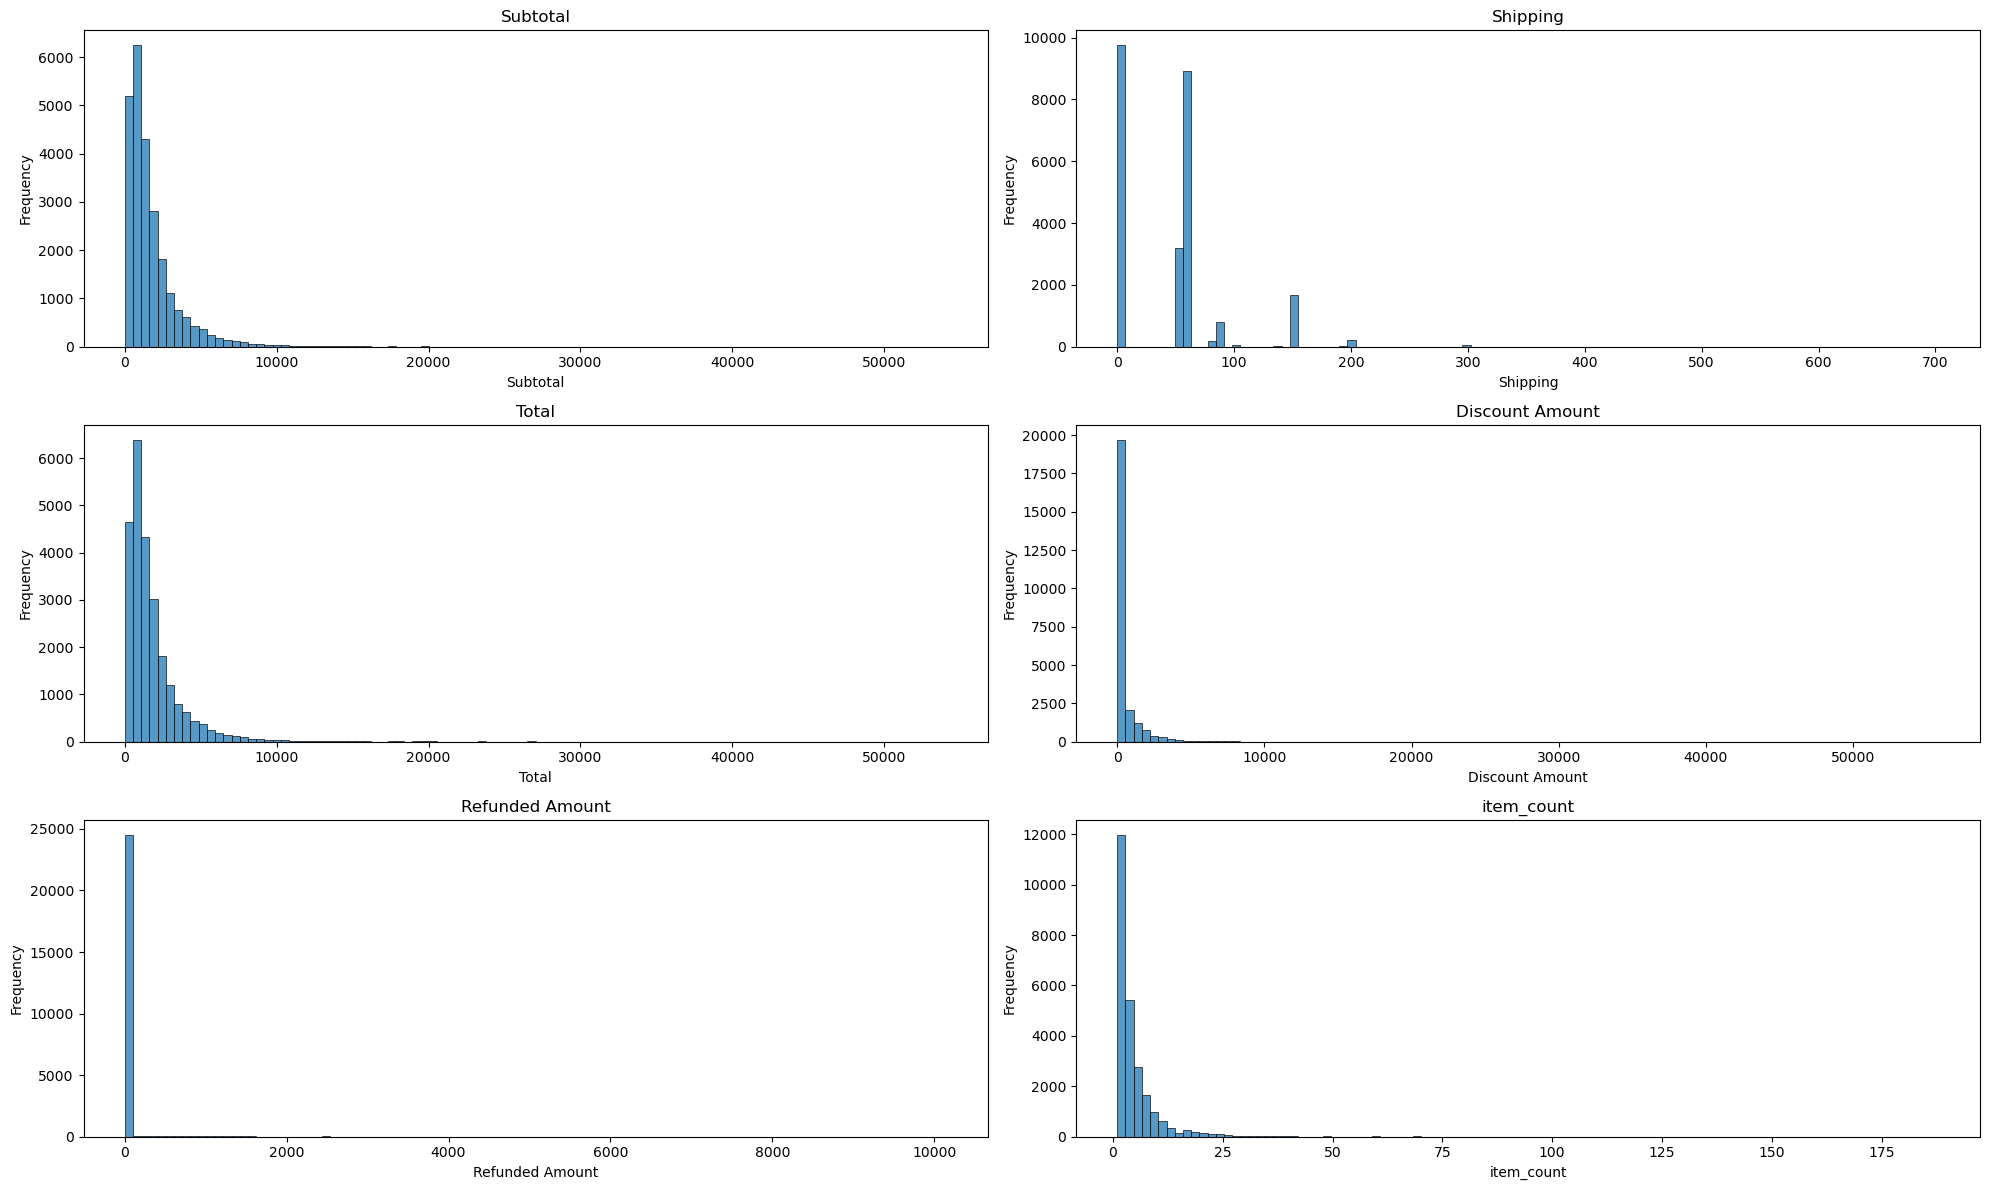

In [20]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(20, 12))

num_cols = len(numerical_columns)
num_rows = (num_cols + 1) // 2 

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(num_rows, 2, i)  
    sns.histplot(x=df[column], bins=100)
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [141]:
import plotly.graph_objects as go
import plotly.colors as pc

colors = pc.qualitative.Dark24[:len(numerical_columns)] 

fig = go.Figure()

for i, (column, color) in enumerate(zip(numerical_columns, colors)):
    fig.add_trace(
        go.Histogram(
            x=df[column], 
            name=column, 
            nbinsx=100, 
            opacity=1,
            marker_color=color,  
            visible=True if i == 0 else False  
        )
    )

dropdown_buttons = [
    {
        "label": column,
        "method": "update",
        "args": [
            {"visible": [i == j for j in range(len(numerical_columns))]},  
            {"title": f"<b>Interactive Histogram: {column}</b>"}
        ]
    }
    for i, column in enumerate(numerical_columns)
]

fig.update_layout(
    title=f"<b>Interactive Histogram: {numerical_columns[0]}</b>",
    xaxis_title="Value",
    yaxis_title="Frequency",
    updatemenus=[{
        "buttons": dropdown_buttons,
        "direction": "down",
        
        "showactive": True,
        "x": 1,
        "y": 1.10,
        "bgcolor": colors[0],
        "bordercolor": "white",
        "font": {"color": "white"},
        "borderwidth": 2  
    }],
    height=600,
    width=1280,
    barmode='overlay'
)

fig.show()



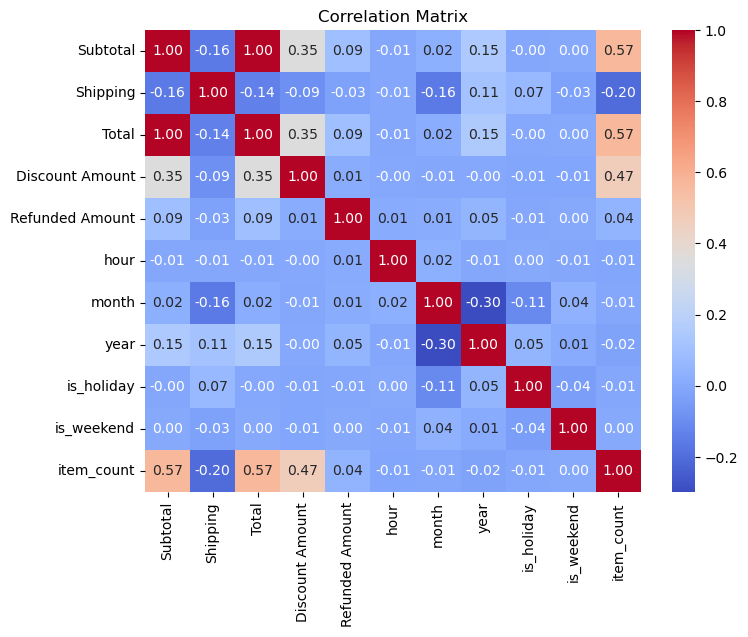

In [50]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [62]:
fig = ff.create_annotated_heatmap(
    z=corr.values, 
    x=list(corr.columns), 
    y=list(corr.index), 
    annotation_text=corr.round(2).values, 
    colorscale="tempo",
    showscale=True
)

fig.update_layout(title="Interactive Correlation Matrix", height=600, width=700)

fig.show()

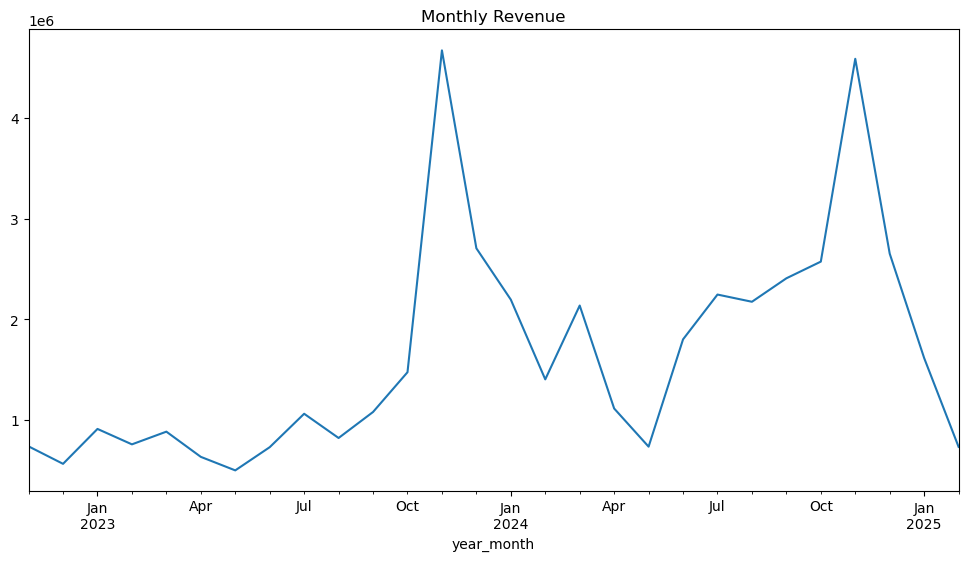

In [22]:
monthly_revenue = df.groupby('year_month')['Total'].sum()
monthly_revenue.plot(kind='line', figsize=(12, 6), title='Monthly Revenue')
plt.show()

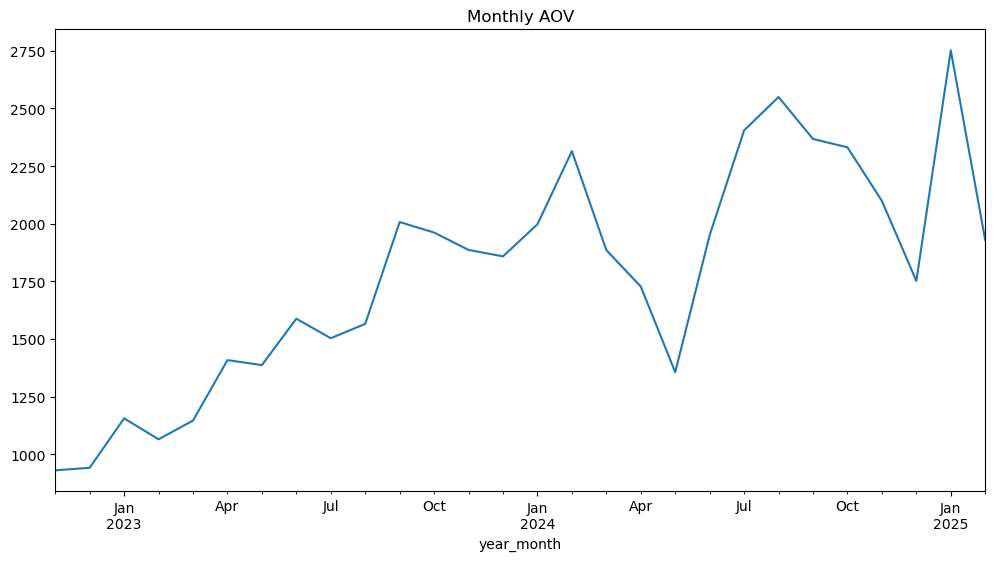

In [23]:
monthly_aov = df.groupby('year_month')['Total'].mean()
monthly_aov.plot(kind='line', figsize=(12, 6), title='Monthly AOV')
plt.show()

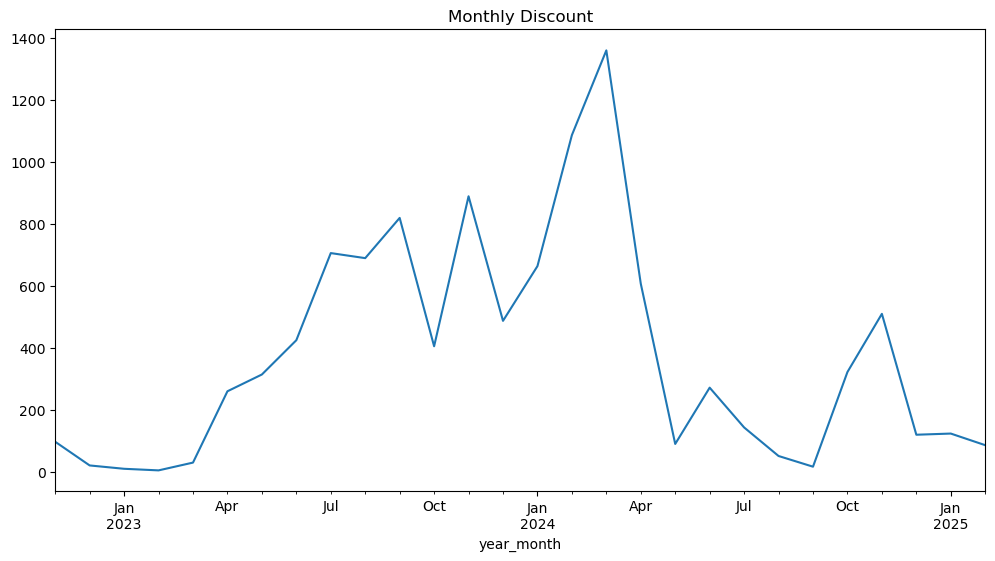

In [24]:
monthly_discount = df.groupby('year_month')['Discount Amount'].mean()
monthly_discount.plot(kind='line', figsize=(12, 6), title='Monthly Discount')
plt.show()

In [67]:
monthly_revenue.index = monthly_revenue.index.astype(str)
monthly_aov.index = monthly_aov.index.astype(str)
monthly_discount.index = monthly_discount.index.astype(str)

colors = ["blue", "green", "red"]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly_revenue.index, y=monthly_revenue, 
    mode='lines+markers', name='Monthly Revenue', 
    line=dict(color=colors[0]), visible=True
))

fig.add_trace(go.Scatter(
    x=monthly_aov.index, y=monthly_aov, 
    mode='lines+markers', name='Monthly AOV', 
    line=dict(color=colors[1]), visible=False
))

fig.add_trace(go.Scatter(
    x=monthly_discount.index, y=monthly_discount, 
    mode='lines+markers', name='Monthly Discount', 
    line=dict(color=colors[2]), visible=False
))

fig.update_layout(
    title="Monthly Metrics Overview",
    xaxis_title="Year-Month",
    yaxis_title="Value",
    height=600,
    width=900,
    hovermode="x unified",
    updatemenus=[
        {
            "buttons": [
                {"label": "Monthly Revenue", "method": "update", 
                 "args": [{"visible": [True, False, False]}, {"title": "Monthly Revenue"}]},
                {"label": "Monthly AOV", "method": "update", 
                 "args": [{"visible": [False, True, False]}, {"title": "Monthly AOV"}]},
                {"label": "Monthly Discount", "method": "update", 
                 "args": [{"visible": [False, False, True]}, {"title": "Monthly Discount"}]},
            ],
            "direction": "down",
            "showactive": True
        }
    ]
)

fig.show()


Lineitem name
Plain Towels 500GSM - 30x30 / Off White    980
Pillow Protector - WHITE / 50*70           833
Plain Towels 500GSM - 30x30 / Grey         824
Plain Towels 500GSM - 30x30 / White        813
Plain Towels 500GSM - 30x30 / Coffee       664
Pillow Protector - GREY / 50*70            663
Plain Towels 500GSM - 30x30 / Mint         634
Golden Christmas Hand Towel                566
Mattress Protector - 180x200 / White       520
Olivia Kitchen Towel 30x50cm - Coffee      503
Olivia Kitchen Towel 30x50cm - Navy        499
Mattress Protector - 120x200 / White       477
Plain Towels 500GSM - 30x30 / Navy         474
Mattress Protector - 160x200 / White       470
Diamond Towel - 30x30 / Off White          460
Hollow Fiber Pillow - 1000gm               459
Waffle Towel - 30x30 / Navy                459
Waffle Towel - 30x30 / Off White           458
Mattress Protector - 180x200 / Grey        445
Waffle Towel - 30x30 / Mint                444
Name: Lineitem quantity, dtype: int64

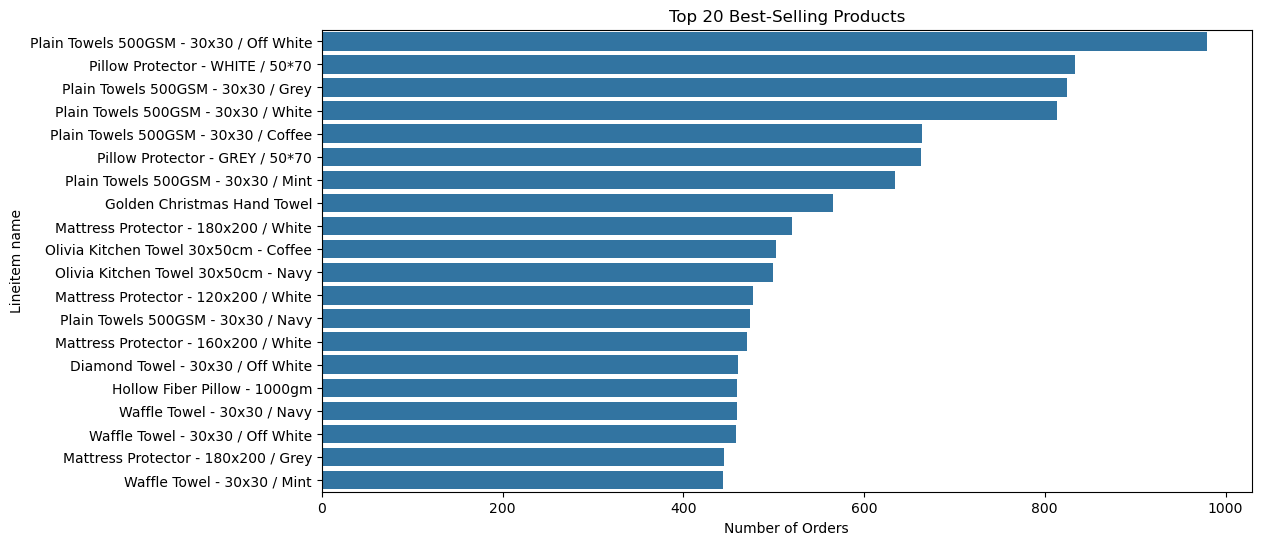

In [25]:
all_products = df['Lineitem name'].explode()
all_products = pd.concat([all_products,df['Lineitem quantity'].explode()],axis=1)
all_products['Lineitem quantity'] = pd.to_numeric(all_products['Lineitem quantity'], errors='coerce')

top_products = all_products.groupby('Lineitem name')['Lineitem quantity'].sum().sort_values(ascending=False).head(20)
    

plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 20 Best-Selling Products')
plt.xlabel('Number of Orders')
top_products

In [ ]:
all_products = df['Lineitem name'].explode()
all_products = pd.concat([all_products, df['Lineitem quantity'].explode()], axis=1)

all_products['Lineitem quantity'] = pd.to_numeric(all_products['Lineitem quantity'], errors='coerce')

top_products = all_products.groupby('Lineitem name')['Lineitem quantity'].sum().sort_values(ascending=False).head(20)

fig = px.bar(
    top_products, 
    x=top_products.values, 
    y=top_products.index, 
    orientation='h',
    title="Top 20 Best-Selling Products",
    labels={'x': 'Number of Orders', 'y': 'Product Name'},
    text=top_products.values,
)

fig.update_layout(
    xaxis_title="Number of Orders", 
    yaxis_title="Product Name", 
    height=600, 
    width=900,
    yaxis={'categoryorder':'total ascending'}
)

fig.update_traces(marker_color='royalblue', textposition='outside')

fig.show()

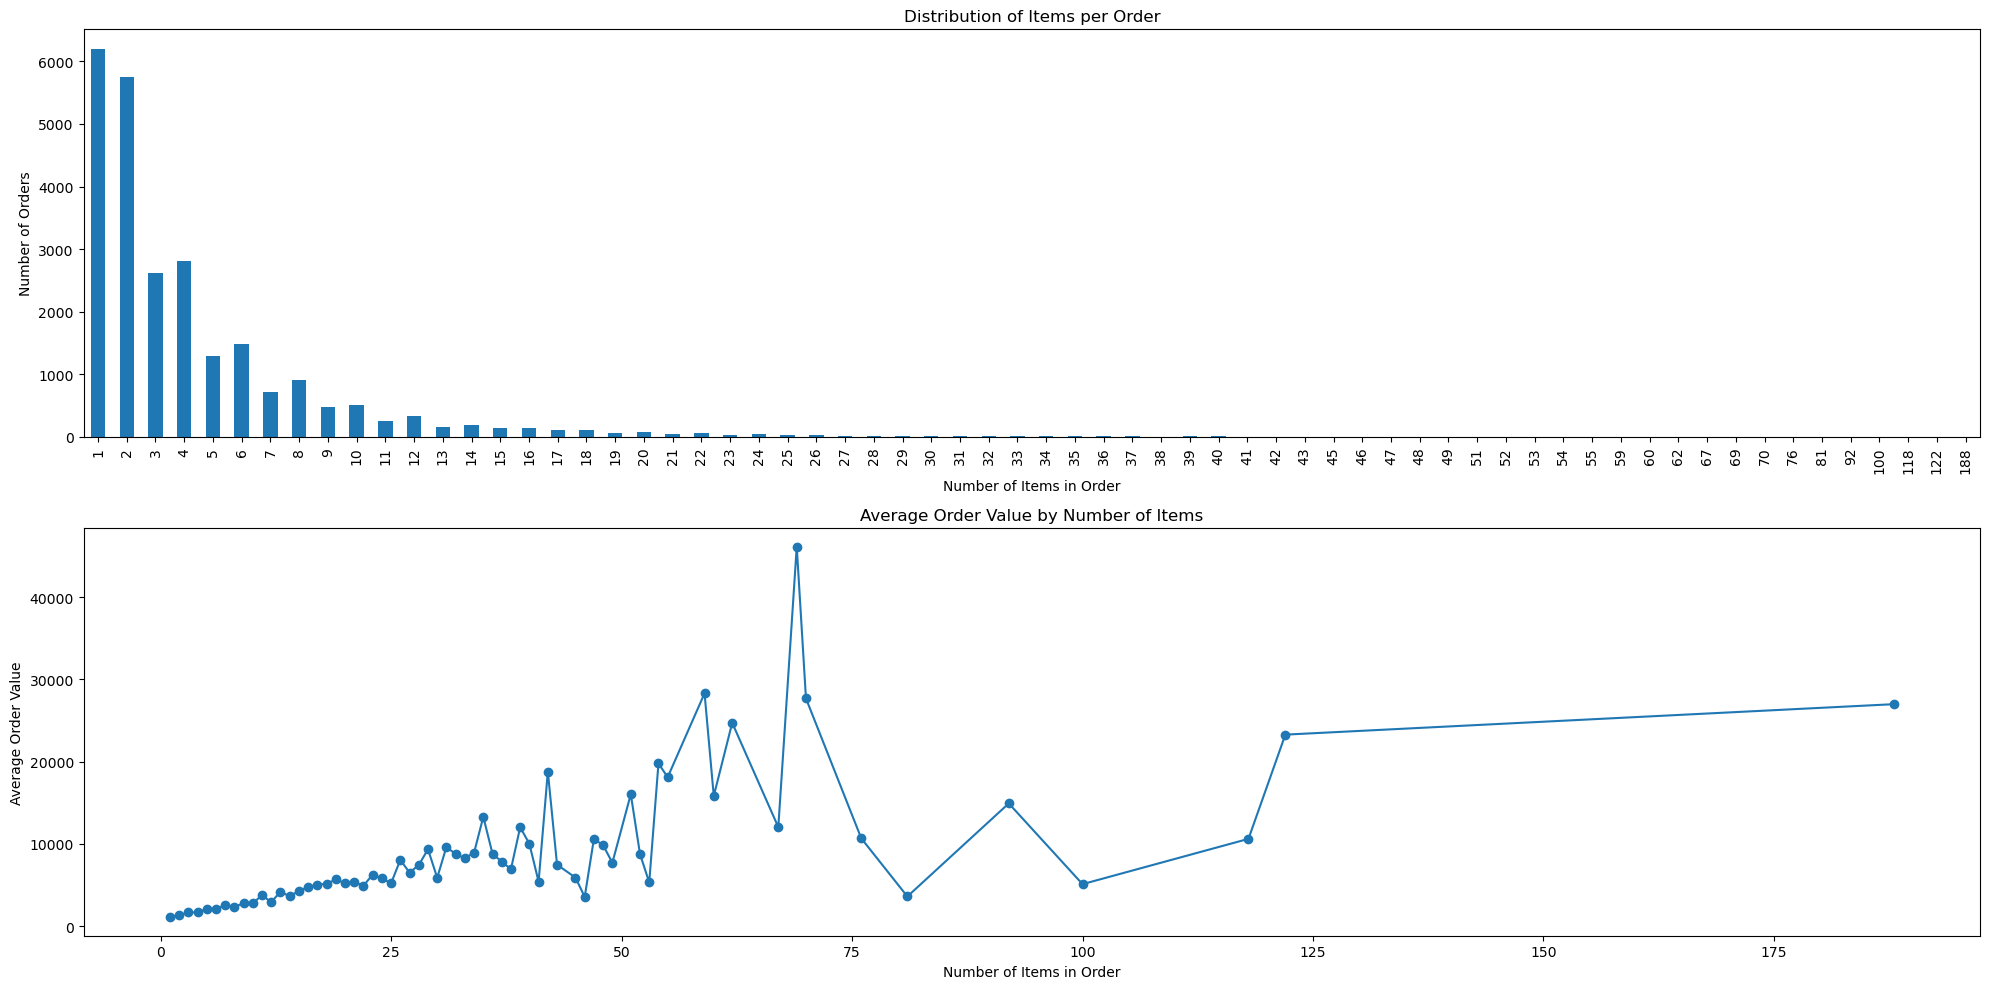


Order Size Summary:
Most common order size: 1 items
Average order size: 4.47 items
Maximum items in an order: 188
Minimum items in an order: 1


In [26]:
plt.figure(figsize=(20, 10))
# Distribution of order sizes
plt.subplot(2, 1, 1)
df['item_count'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Items per Order')
plt.xlabel('Number of Items in Order')
plt.ylabel('Number of Orders')

# Average order value by number of items
plt.subplot(2, 1, 2)
avg_order_value = df.groupby('item_count')['Total'].mean()
avg_order_value.plot(kind='line', marker='o')
plt.title('Average Order Value by Number of Items')
plt.xlabel('Number of Items in Order')
plt.ylabel('Average Order Value')

plt.tight_layout()
plt.show()

# Summary statistics
print("\nOrder Size Summary:")
print(f"Most common order size: {df['item_count'].mode().values[0]} items")
print(f"Average order size: {df['item_count'].mean():.2f} items")
print(f"Maximum items in an order: {df['item_count'].max()}")
print(f"Minimum items in an order: {df['item_count'].min()}")



In [75]:
order_size_counts = df['item_count'].value_counts().sort_index()

avg_order_value = df.groupby('item_count')['Total'].mean()

fig = sp.make_subplots(
    rows=2, cols=1, 
    subplot_titles=["Distribution of Items per Order", "Average Order Value by Number of Items"]
)

fig.add_trace(
    go.Bar(x=order_size_counts.index, y=order_size_counts.values, name="Order Size Distribution"),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=avg_order_value.index, y=avg_order_value.values, mode='lines+markers', name="Average Order Value"),
    row=2, col=1
)

fig.update_layout(
    height=800, width=1280, 
    title_text="Order Size and Value Analysis",
    xaxis_title="Number of Items in Order",
    yaxis_title="Number of Orders",
    showlegend=False
)

fig.show()

print("\nOrder Size Summary:")
print(f"Most common order size: {df['item_count'].mode().values[0]} items")
print(f"Average order size: {df['item_count'].mean():.2f} items")
print(f"Maximum items in an order: {df['item_count'].max()}")
print(f"Minimum items in an order: {df['item_count'].min()}")


Order Size Summary:
Most common order size: 1 items
Average order size: 4.47 items
Maximum items in an order: 188
Minimum items in an order: 1


In [27]:
day_analysis = df.groupby('day_type').agg({
    'Total': ['count', 'mean', 'sum'],
    'item_count': ['sum'] 
}).round(2)

day_analysis.columns = ['count', 'mean', 'sum', 'items_count']

day_analysis = day_analysis.reindex(['Holiday', 'Weekday', 'Weekend'])

print("\nSales Analysis by Day Type:")
print(day_analysis)


print("\nItem Analysis:")
print(f"Average items per order: {df['item_count'].mean():.2f}")
print(f"Maximum items in an order: {df['item_count'].max()}")
print(f"Minimum items in an order: {df['item_count'].min()}")


Sales Analysis by Day Type:
          count     mean          sum  items_count
day_type                                          
Holiday     843  1804.65   1521319.14         3610
Weekday   16740  1839.30  30789799.99        74769
Weekend    7273  1858.90  13519792.57        32605

Item Analysis:
Average items per order: 4.47
Maximum items in an order: 188
Minimum items in an order: 1


In [100]:

yearly_orders = df.groupby('year').agg({
    'Name': 'count',
    'Total': 'sum'
}).rename(columns={'Name': 'order_count'})

seasonal_analysis = df.groupby('season',observed=False).agg({
    'Name': 'count',
    'Total': ['mean', 'sum'],
})
seasonal_orders = df.groupby(['year', 'season'],observed=False)['Total'].sum().unstack()


monthly_trend = df.groupby('year_month').agg({
    'Name': 'count',
    'Total': 'sum'
})

province_yearly = df.groupby(['year', 'Shipping Province Name']).agg({
    'Name': 'count',
    'Total': 'sum'
})

pivot_province = province_yearly.reset_index().pivot(
    index='Shipping Province Name', 
    columns='year', 
    values='Total'
)



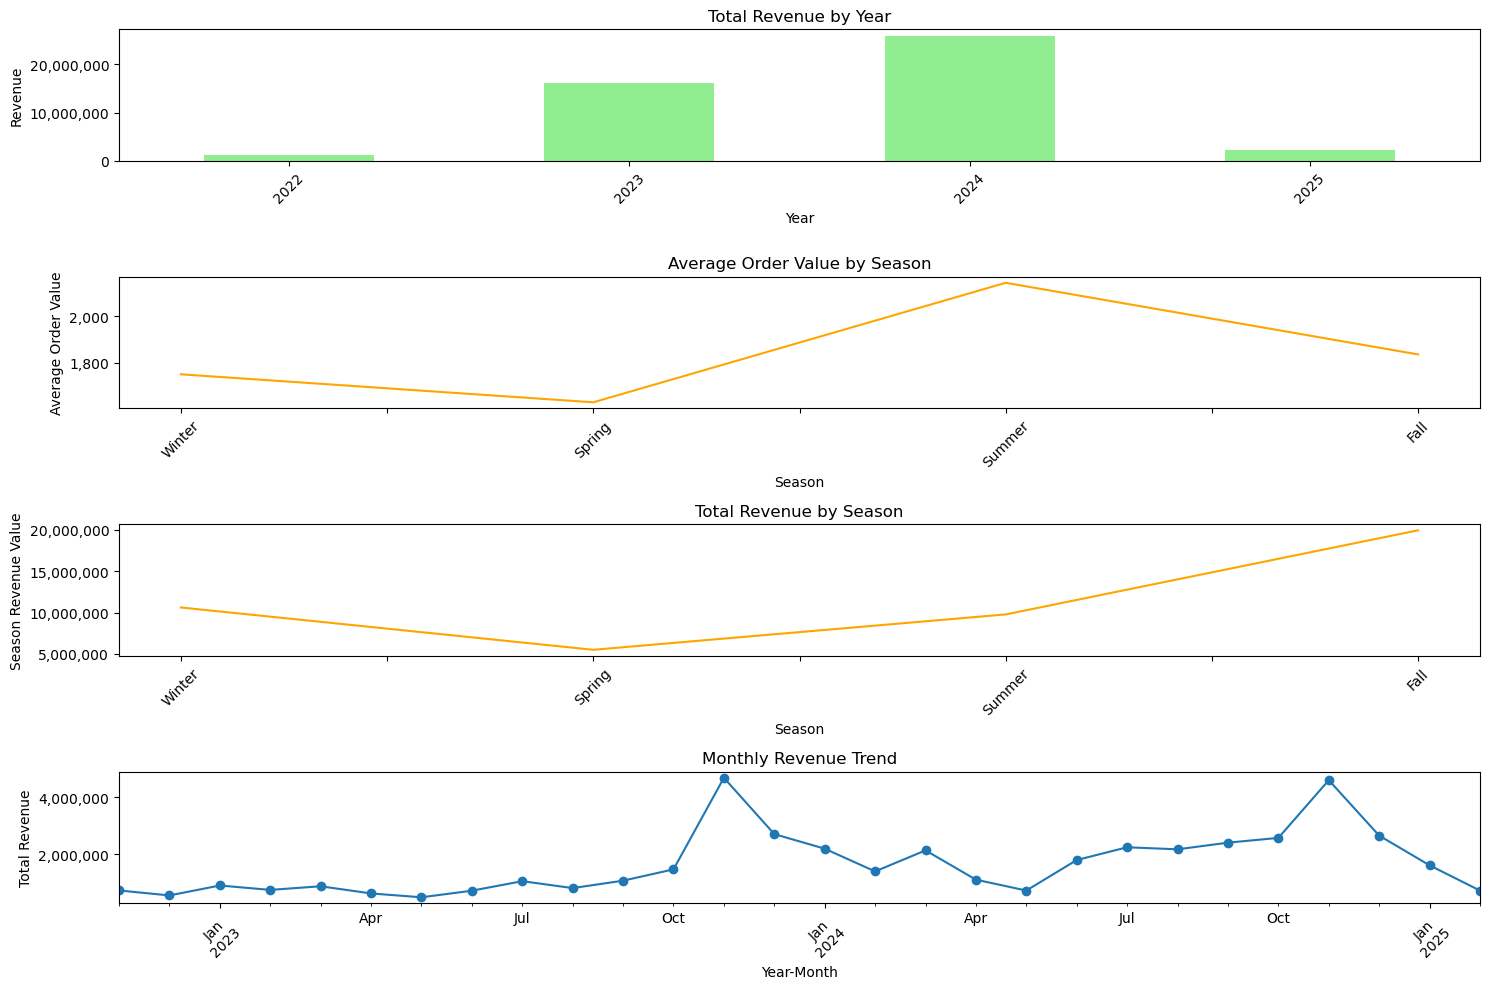

In [29]:
plt.figure(figsize=(15, 10))

# Yearly revenue subplot
plt.subplot(4, 1, 1)
ax1 = yearly_orders['Total'].plot(kind='bar', y='Total', color='lightgreen')
plt.title('Total Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Revenue')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=45)

#  Seasonal Analysis
plt.subplot(4, 1, 2)
ax2 = seasonal_analysis['Total']['mean'].plot(kind='line',y='mean', color='orange')
plt.title('Average Order Value by Season')
plt.xlabel('Season')
plt.ylabel('Average Order Value')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=45)

#  Seasonal Analysis
plt.subplot(4, 1, 3)
ax3 = seasonal_analysis['Total']['sum'].plot(kind='line',y='sum', color='orange')
plt.title('Total Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Season Revenue Value')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=45)

#  Monthly Trend
plt.subplot(4,1, 4)
ax4 = monthly_trend['Total'].plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



In [ ]:
yearly_orders.index = yearly_orders.index.astype(str)
seasonal_analysis.index = seasonal_analysis.index.astype(str)
monthly_trend.index = monthly_trend.index.astype(str)

fig = sp.make_subplots(
    rows=4, cols=1, 
    subplot_titles=[
        "Total Revenue by Year",
        "Average Order Value by Season",
        "Total Revenue by Season",
        "Monthly Revenue Trend"
    ],
    vertical_spacing=0.15
)

fig.add_trace(
    go.Bar(x=yearly_orders.index, y=yearly_orders['Total'], marker_color="lightgreen", name="Total Revenue"),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=seasonal_analysis.index, y=seasonal_analysis['Total']['mean'], 
               mode='lines+markers', line=dict(color="orange"), name="Avg Order Value"),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(x=seasonal_analysis.index, y=seasonal_analysis['Total']['sum'], 
               mode='lines+markers', line=dict(color="red"), name="Total Revenue"),
    row=3, col=1
)

fig.add_trace(
    go.Scatter(x=monthly_trend.index, y=monthly_trend['Total'], 
               mode='lines+markers', line=dict(color="blue"), name="Monthly Revenue"),
    row=4, col=1
)

fig.update_layout(
    height=1000, width=1280, 
    title="Revenue & Seasonal Analysis",
    showlegend=False,  
    xaxis4=dict(title="Year-Month"),
    xaxis3=dict(title="Season"),
    xaxis2=dict(title="Season"),
    xaxis1=dict(title="Year"),
    yaxis1=dict(title="Revenue"),
    yaxis2=dict(title="Average Order Value"),
    yaxis3=dict(title="Total Revenue"),
    yaxis4=dict(title="Total Revenue"),
)

fig.show()

<Figure size 1500x1000 with 0 Axes>

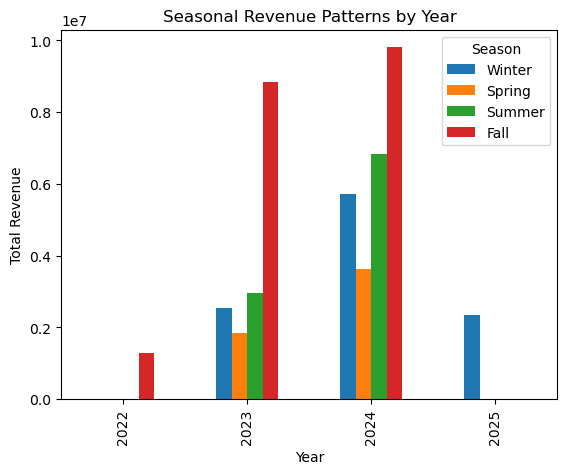

In [30]:
plt.figure(figsize=(15,10))


seasonal_orders.plot(kind='bar')
plt.title('Seasonal Revenue Patterns by Year')
plt.xlabel('Year')
plt.ylabel('Total Revenue')
plt.legend(title='Season')

plt.show()

In [ ]:
seasonal_orders.index = seasonal_orders.index.astype(str)

fig = px.bar(
    seasonal_orders, 
    x=seasonal_orders.index, 
    y=seasonal_orders.columns,  
    title="Seasonal Revenue Patterns by Year",
    labels={"value": "Total Revenue", "variable": "Season", "x": "Year"},
    barmode="group"
)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Total Revenue",
    legend_title="Season",
    height=600,
    width=900
)

fig.show()

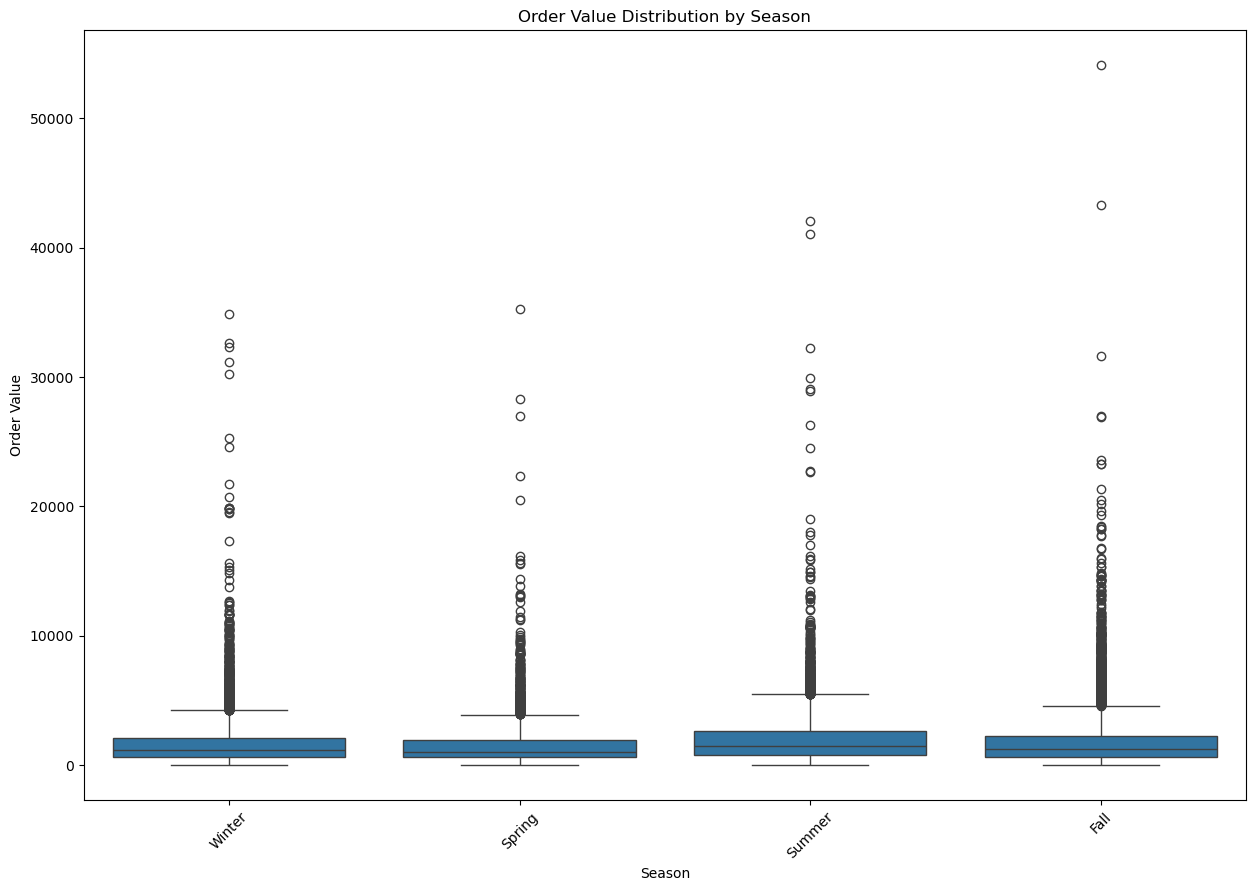

In [31]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df, x='season', y='Total')
plt.title('Order Value Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Order Value')
plt.xticks(rotation=45)

plt.show()

In [84]:
fig = px.box(
    df, 
    x="season", 
    y="Total", 
    title="Order Value Distribution by Season",
    labels={"Total": "Order Value", "season": "Season"},
)

fig.update_layout(
    xaxis_title="Season",
    yaxis_title="Order Value",
    height=600,
    width=900
)

fig.show()

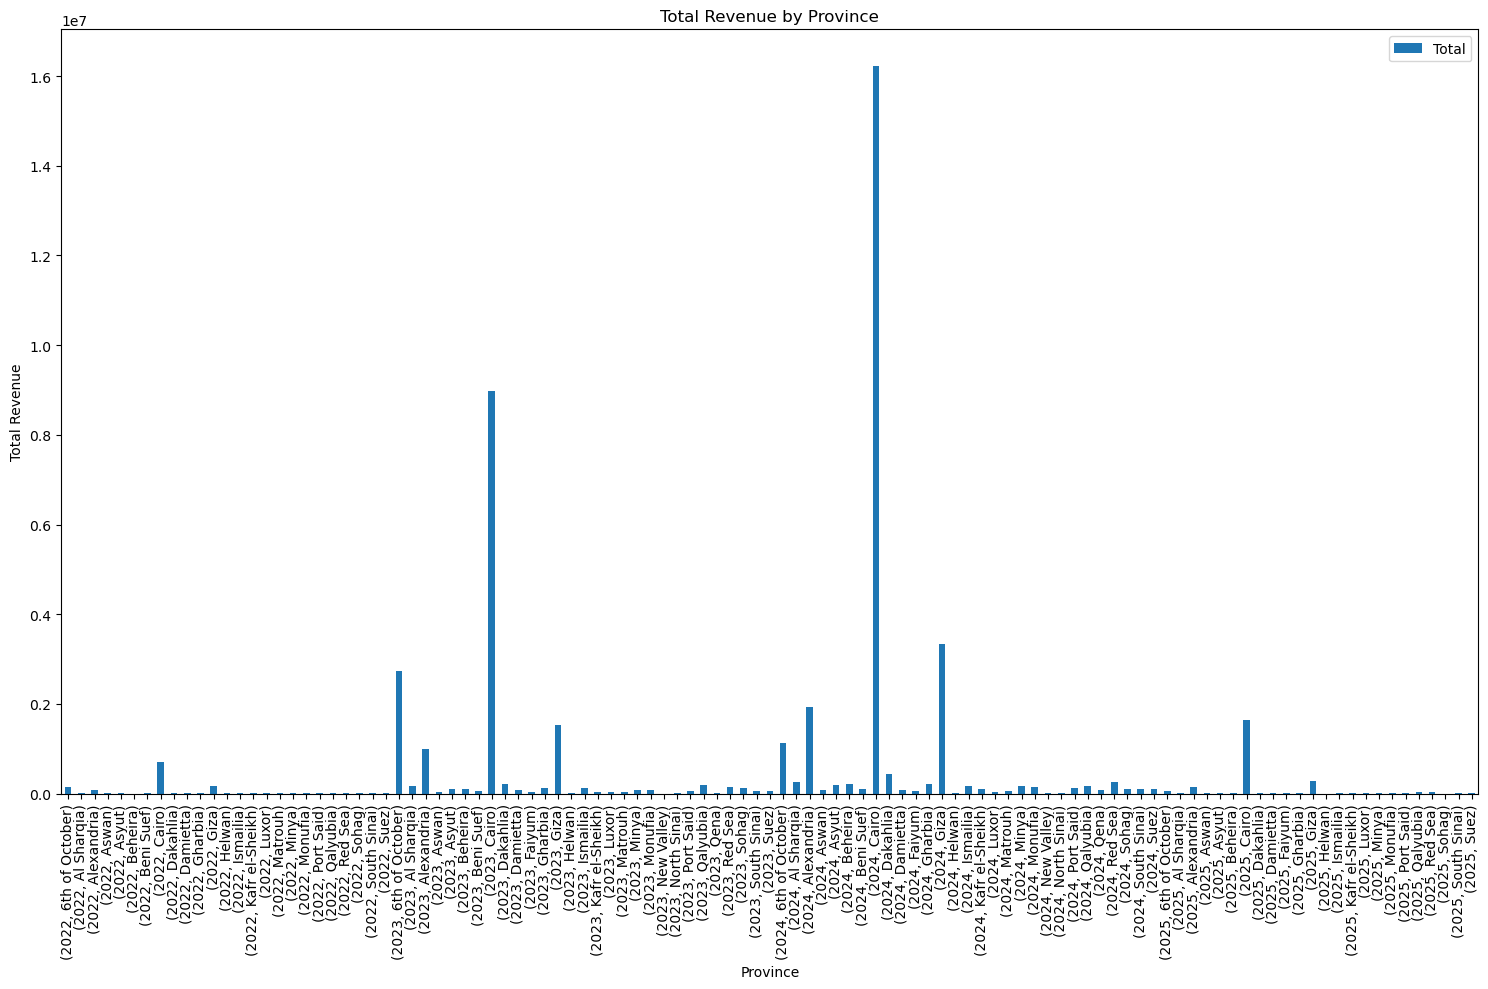

In [32]:
province_yearly.plot(kind='bar', y='Total', figsize=(15, 10))
plt.title('Total Revenue by Province')
plt.xlabel('Province')
plt.ylabel('Total Revenue')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

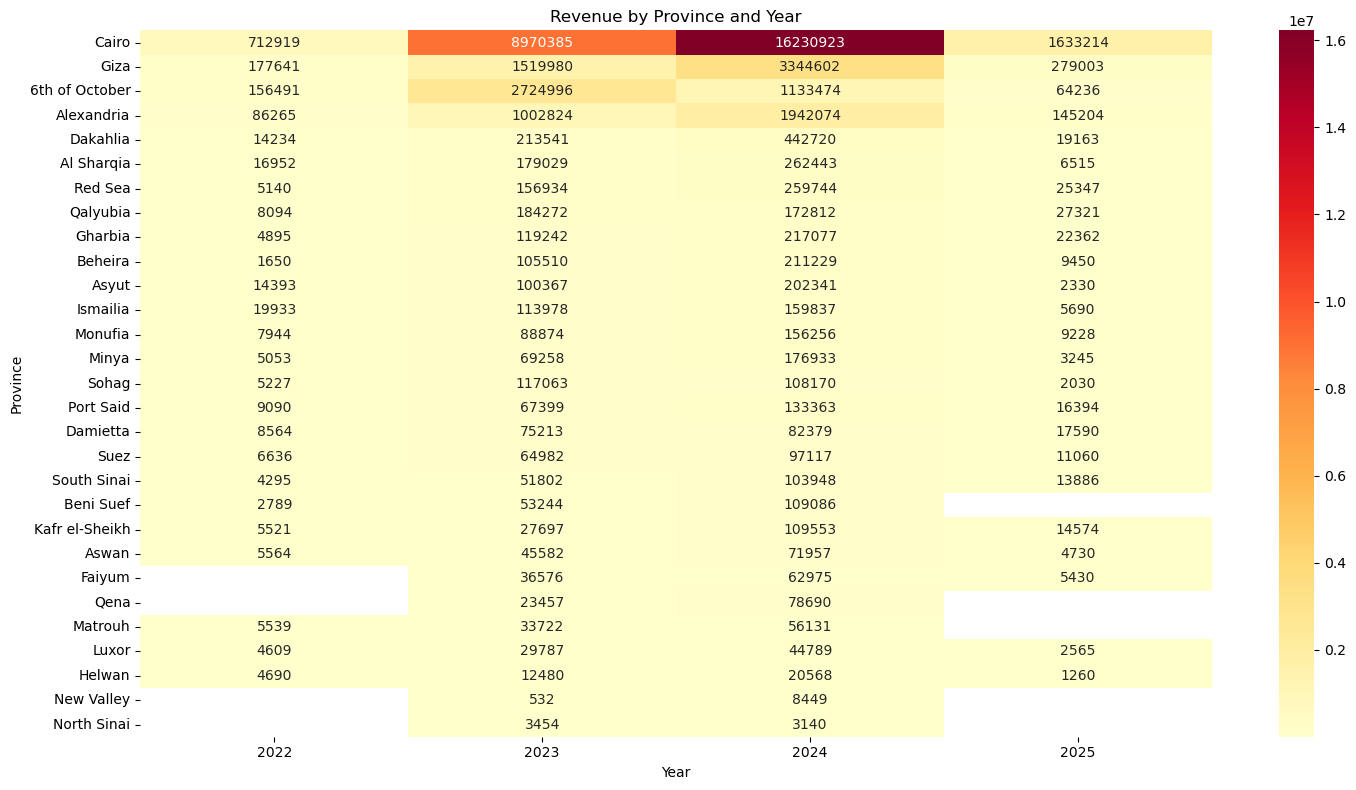

In [101]:

plt.figure(figsize=(15, 8))
province_totals = pivot_province.sum(axis=1).sort_values(ascending=False)
pivot_province_sorted = pivot_province.reindex(province_totals.index)
sns.heatmap(pivot_province_sorted, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Revenue by Province and Year')
plt.xlabel('Year')
plt.ylabel('Province')
plt.tight_layout()
plt.show()


In [34]:
yoy_growth = ((yearly_orders - yearly_orders.shift(1)) / yearly_orders.shift(1)) * 100

mom_growth = ((monthly_trend - monthly_trend.shift(1)) / monthly_trend.shift(1)) * 100



product_prices = []
for idx, row in df.iterrows():
    year = row['Created at'].year
    for price, product in zip(row['Lineitem price'], row['Lineitem name']):
        product_prices.append({
            'year': year,
            'product': product,
            'price': price
        })

product_df = pd.DataFrame(product_prices)

yearly_prices = product_df.groupby(['year', 'product'])['price'].mean().reset_index()

price_pivot = yearly_prices.pivot(index='product', columns='year', values='price')

yoy_changes = pd.DataFrame()
for year in range(price_pivot.columns.min()+1, price_pivot.columns.max()+1):
    
    yoy = ((price_pivot[year] - price_pivot[year-1]) / price_pivot[year-1] * 100)

    yoy = yoy.replace([np.inf, -np.inf], np.nan)
    yoy_changes[f'{year}_YoY%'] = yoy

    

final_analysis = pd.concat([price_pivot, yoy_changes], axis=1)

final_analysis = final_analysis.sort_index()




yoy_changes['Avg_Change'] = yoy_changes.abs().mean(axis=1)
print("\nOverall Price Change Statistics:")
for year in yoy_changes.columns:
    if year != 'Avg_Change':
        print(f"\nYear {year}:")
        print(f"Average Change: {yoy_changes[year].mean():.2f}%")
        print(f"Median Change: {yoy_changes[year].median():.2f}%")
        print(f"Max Increase: {yoy_changes[year].max():.2f}%")
        print(f"Max Decrease: {yoy_changes[year].min():.2f}%")





Overall Price Change Statistics:

Year 2023_YoY%:
Average Change: 47.49%
Median Change: 28.38%
Max Increase: 351.11%
Max Decrease: -53.89%

Year 2024_YoY%:
Average Change: 28.42%
Median Change: 17.65%
Max Increase: 224.66%
Max Decrease: -46.37%

Year 2025_YoY%:
Average Change: -1.24%
Median Change: 0.00%
Max Increase: 104.55%
Max Decrease: -74.29%


In [35]:
print("\nSummary Statistics of Year-over-Year Price Changes:")
yoy_changes.describe()


Summary Statistics of Year-over-Year Price Changes:


,2023_YoY%,2024_YoY%,2025_YoY%,Avg_Change
count,454.000000,607.000000,333.000000,1249.000000
mean,47.490116,28.418311,-1.242612,38.105332
std,64.932949,43.237484,36.405764,37.280631
min,-53.887181,-46.372240,-74.285714,0.000000
25%,0.000000,-1.110191,-32.145305,11.461582
50%,28.375365,17.647059,0.000000,27.365963
75%,83.048981,52.810248,25.585023,50.651314
max,351.111111,224.658003,104.545455,265.151786


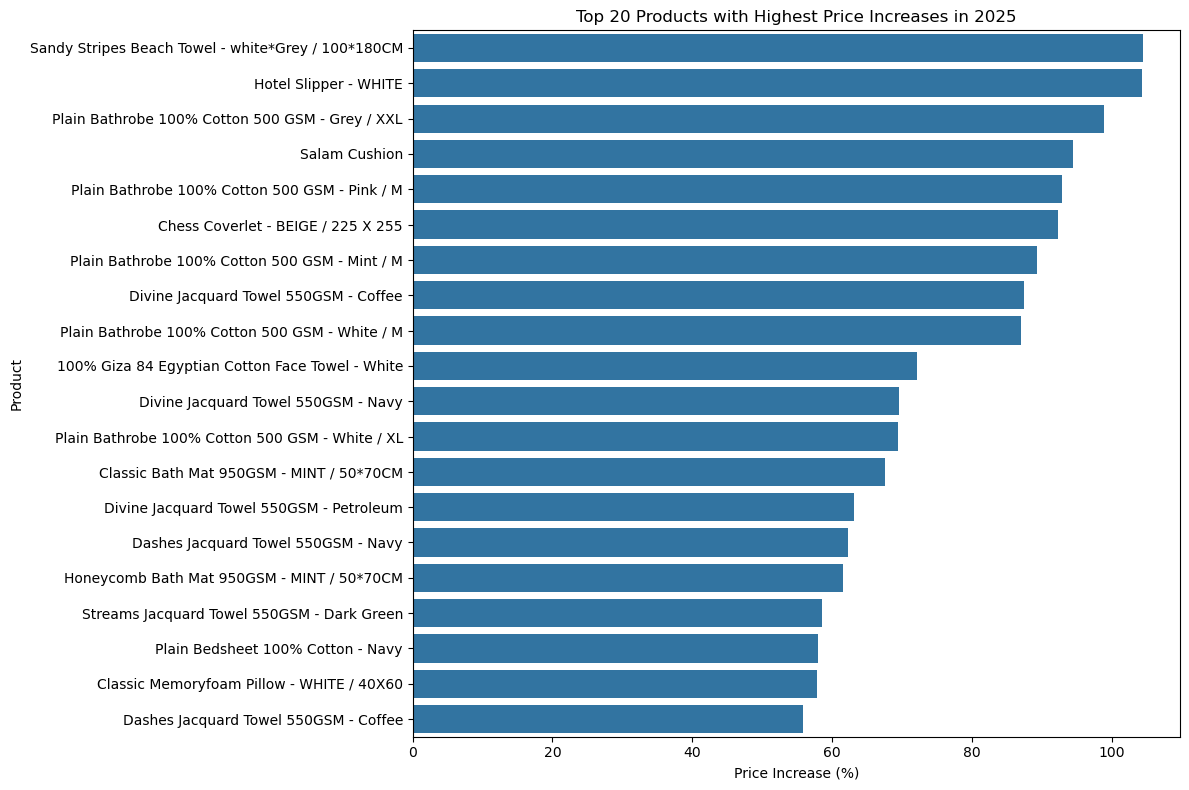

In [ ]:
plt.figure(figsize=(12,8))

latest_year = f'{price_pivot.columns.max()}_YoY%'
top_20_increases = yoy_changes[latest_year].sort_values(ascending=False).head(20)

sns.barplot(x=top_20_increases.values, y=top_20_increases.index)
plt.title(f'Top 20 Products with Highest Price Increases in {price_pivot.columns.max()}')
plt.xlabel('Price Increase (%)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [ ]:
latest_year = f'{price_pivot.columns.max()}_YoY%'

top_20_increases = yoy_changes[latest_year].sort_values(ascending=False).head(20)

fig = px.bar(
    x=top_20_increases.values,
    y=top_20_increases.index,  
    orientation="h",  
    title=f"Top 20 Products with Highest Price Increases in {price_pivot.columns.max()}",
    labels={"x": "Price Increase (%)", "y": "Product"},
    color=top_20_increases.values, 
    color_continuous_scale="Reds"
)

fig.update_layout(
    xaxis_title="Price Increase (%)",
    yaxis_title="Product",
    height=600,
    width=900,
    yaxis=dict(categoryorder="total ascending")
)

fig.show()


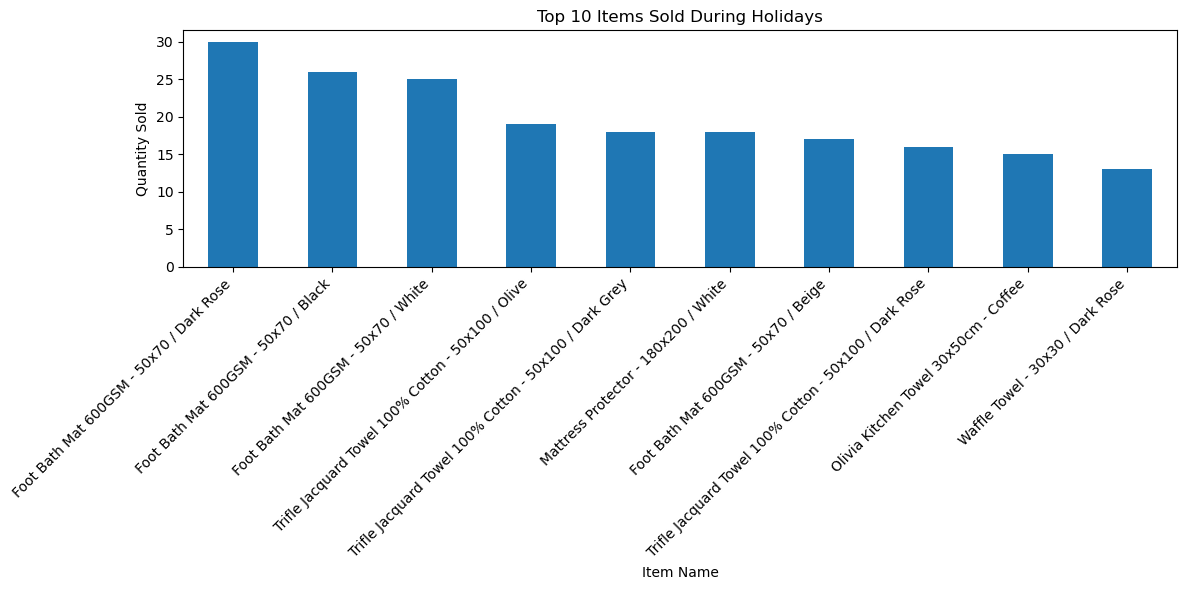

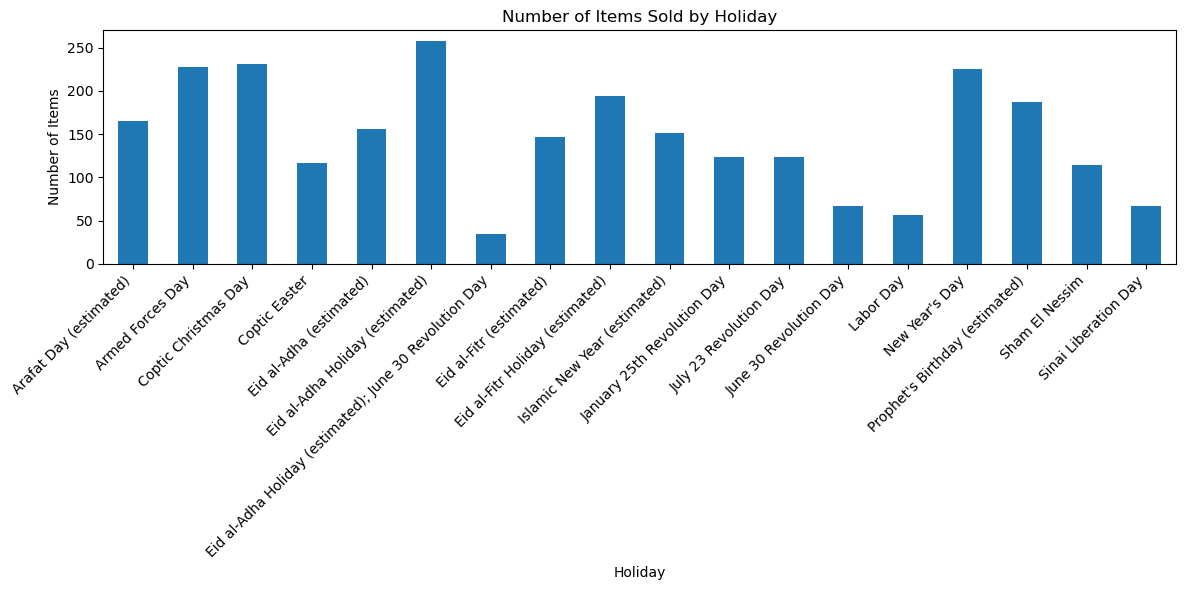

In [37]:
if df['is_holiday'].any():
    holiday_items = []
    
    # Process each holiday order
    holiday_orders = df[df['is_holiday']]
    for _, row in holiday_orders.iterrows():
        items = row['Lineitem name']
        prices = row['Lineitem price']
        holiday = row['holiday_name']

        for item, price in zip(items, prices):
            holiday_items.append({
                'holiday': holiday,
                'item': item.strip(),
                'price': float(price),
                'date': row['Created at']
            })
    
    holiday_items_df = pd.DataFrame(holiday_items)
    

    holiday_analysis = holiday_items_df.groupby(['holiday', 'item']).agg({
        'item': 'count',
        'price': ['mean', 'sum']
    }).round(2)
    
    holiday_analysis.columns = ['quantity_sold', 'avg_price', 'total_revenue']
    

    
    # Top items sold during holidays
    top_holiday_items = holiday_items_df.groupby('item')['item'].count().sort_values(ascending=False).head(10)
    
    plt.figure(figsize=(12, 6))
    top_holiday_items.plot(kind='bar')
    plt.title('Top 10 Items Sold During Holidays')
    plt.xlabel('Item Name')
    plt.ylabel('Quantity Sold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Sales distribution by holiday
    plt.figure(figsize=(12, 6))
    holiday_items_df.groupby('holiday')['item'].count().plot(kind='bar')
    plt.title('Number of Items Sold by Holiday')
    plt.xlabel('Holiday')
    plt.ylabel('Number of Items')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


In [113]:
if df['is_holiday'].any():
    holiday_items = []

    holiday_orders = df[df['is_holiday']]
    for _, row in holiday_orders.iterrows():
        items = row['Lineitem name']
        prices = row['Lineitem price']
        holiday = row['holiday_name']

        for item, price in zip(items, prices):
            holiday_items.append({
                'holiday': holiday,
                'item': item.strip(),
                'price': float(price),
                'date': row['Created at']
            })

    holiday_items_df = pd.DataFrame(holiday_items)

    holiday_analysis = holiday_items_df.groupby(['holiday', 'item']).agg({
        'item': 'count',
        'price': ['mean', 'sum']
    }).round(2)
    
    holiday_analysis.columns = ['quantity_sold', 'avg_price', 'total_revenue']

    top_holiday_items = holiday_items_df.groupby('item')['item'].count().sort_values(ascending=False).head(10)
    fig1 = px.bar(
        x=top_holiday_items.index,
        y=top_holiday_items.values,
        title="Top 10 Items Sold During Holidays",
        labels={"x": "Item Name", "y": "Quantity Sold"},
        color=top_holiday_items.values,
        color_continuous_scale="Blues"
    )
    fig1.update_layout(xaxis_tickangle=-45, height=500, width=1280)
    fig1.show()

    holiday_sales = holiday_items_df.groupby('holiday')['item'].count()
    fig2 = px.bar(
        x=holiday_sales.index,
        y=holiday_sales.values,
        title="Number of Items Sold by Holiday",
        labels={"x": "Holiday", "y": "Number of Items"},
        color=holiday_sales.values,
        color_continuous_scale="Oranges"
    )
    fig2.update_layout(xaxis_tickangle=-45, height=500, width=1280)
    fig2.show()

Text(0, 0.5, 'Frequency')

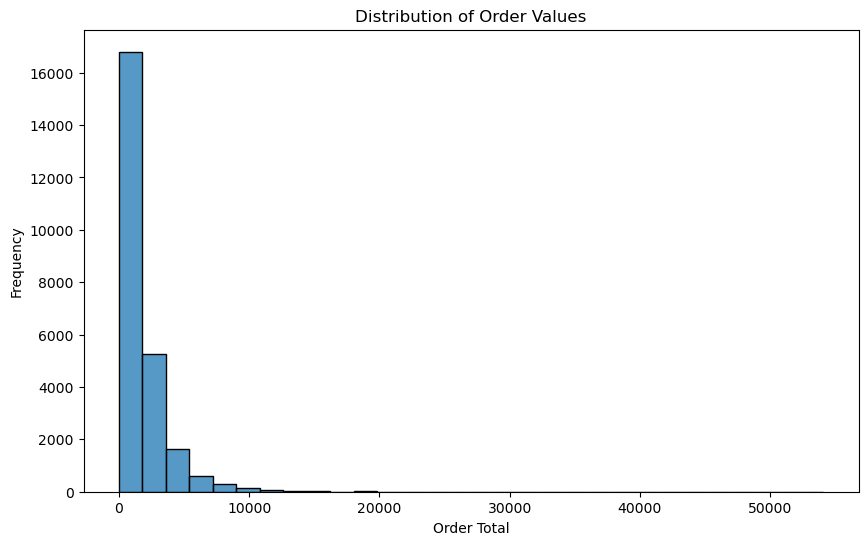

In [38]:
plt.figure(figsize=(10,6))
sns.histplot(df['Subtotal'], bins=30)
plt.title('Distribution of Order Values')
plt.xlabel('Order Total')
plt.ylabel('Frequency')

In [ ]:
fig = px.histogram(
    df, 
    x="Subtotal", 
    nbins=30, 
    title="Distribution of Order Values", 
    labels={"Subtotal": "Order Total", "count": "Frequency"}, 
    color_discrete_sequence=["royalblue"]
)

fig.update_layout(
    bargap=0.1,
    height=500, width=800
)

fig.show()
